
DATA CLEANING AND VISUALIZATION PROJECT




STEP 1: Importing the required libraries

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

STEP 2 : load the dataset

In [26]:
df = pd.read_csv("/content/amazon.csv.zip")
print(df)

      product_id                                       product_name  \
0     B07JW9H4J1  Wayona Nylon Braided USB to Lightning Fast Cha...   
1     B098NS6PVG  Ambrane Unbreakable 60W / 3A Fast Charging 1.5...   
2     B096MSW6CT  Sounce Fast Phone Charging Cable & Data Sync U...   
3     B08HDJ86NZ  boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...   
4     B08CF3B7N1  Portronics Konnect L 1.2M Fast Charging 3A 8 P...   
...          ...                                                ...   
1460  B08L7J3T31  Noir Aqua - 5pcs PP Spun Filter + 1 Spanner | ...   
1461  B01M6453MB  Prestige Delight PRWO Electric Rice Cooker (1 ...   
1462  B009P2LIL4  Bajaj Majesty RX10 2000 Watts Heat Convector R...   
1463  B00J5DYCCA  Havells Ventil Air DSP 230mm Exhaust Fan (Pist...   
1464  B01486F4G6  Borosil Jumbo 1000-Watt Grill Sandwich Maker (...   

                                               category discounted_price  \
0     Computers&Accessories|Accessories&Peripherals|...             ₹39

STEP 3 : checking
 missing values

In [27]:
print("\nMissing Values in Each Column:")
print(df.isnull().sum())
df['product_name'] = df['product_name'].fillna('Unknown')
df['category'] = df['category'].fillna('Unknown')



Missing Values in Each Column:
product_id             0
product_name           0
category               0
discounted_price       0
actual_price           0
discount_percentage    0
rating                 0
rating_count           2
about_product          0
user_id                0
user_name              0
review_id              0
review_title           0
review_content         0
img_link               0
product_link           0
dtype: int64


STEP 4 : handling missing values

In [28]:
# Handle Missing Values and Convert Data Types

# Fill missing values in 'rating_count' with the mode (most frequent value)
df['rating_count'] = df['rating_count'].fillna(df['rating_count'].mode()[0])

# Remove commas and convert 'rating_count' to integer
df['rating_count'] = df['rating_count'].astype(str).str.replace(',', '').astype(int)

# Replace '—' and other non-numeric characters in 'rating', then convert to float
df['rating'] = pd.to_numeric(
    df['rating'].astype(str).str.replace('—', '').str.replace('[^0-9.]', '', regex=True),
    errors='coerce'
)

# Fill missing values in 'rating' with the mean
df['rating'] = df['rating'].fillna(df['rating'].mean())

# Check data types and missing values after cleaning
print(df[['rating', 'rating_count']].dtypes)
print(df[['rating', 'rating_count']].isnull().sum())

rating          float64
rating_count      int64
dtype: object
rating          0
rating_count    0
dtype: int64


STEP 5: Cleaning and Converting Price and Discount Columns



In [29]:
print('Original dtypes:')
print(df[['discounted_price', 'actual_price', 'discount_percentage']].dtypes)

# Function to clean and convert price columns
def clean_price(price_str):
    return float(price_str.replace('₹', '').replace(',', ''))

# Apply cleaning to price columns
df['discounted_price'] = df['discounted_price'].apply(clean_price)
df['actual_price'] = df['actual_price'].apply(clean_price)

# Clean and convert discount_percentage
df['discount_percentage'] = df['discount_percentage'].str.replace('%', '').astype(float)

print('\nAfter cleaning and converting types:')
print(df[['discounted_price', 'actual_price', 'discount_percentage']].dtypes)

# Display first 5 rows with cleaned columns
display(df[['discounted_price', 'actual_price', 'discount_percentage', 'rating', 'rating_count']].head())

Original dtypes:
discounted_price       object
actual_price           object
discount_percentage    object
dtype: object

After cleaning and converting types:
discounted_price       float64
actual_price           float64
discount_percentage    float64
dtype: object


,discounted_price,actual_price,discount_percentage,rating,rating_count
0,399.0,1099.0,64.0,4.2,24269
1,199.0,349.0,43.0,4.0,43994
2,199.0,1899.0,90.0,3.9,7928
3,329.0,699.0,53.0,4.2,94363
4,154.0,399.0,61.0,4.2,16905


STEP 6 : checking duplicate rows

In [30]:
# Check number of duplicate rows
print("Duplicate Rows:", df.duplicated().sum())

# Remove duplicate rows
df = df.drop_duplicates()

# Verify duplicates are removed
print("Duplicate Rows After Removal:", df.duplicated().sum())

Duplicate Rows: 0
Duplicate Rows After Removal: 0


STEP 7: detecting and removing outliers

In [31]:
# Detect and Remove Outliers using IQR Method
# We will remove outliers from the 'discounted_price' column

# Calculate Q1 (25th percentile)
Q1 = df['discounted_price'].quantile(0.25)

# Calculate Q3 (75th percentile)
Q3 = df['discounted_price'].quantile(0.75)

# Calculate Interquartile Range (IQR)
IQR = Q3 - Q1

# Calculate lower and upper bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Remove outliers
df_clean = df[
    (df['discounted_price'] >= lower_bound) &
    (df['discounted_price'] <= upper_bound)
]

# Check number of rows before and after removing outliers
print("Original Rows:", len(df))
print("Rows After Outlier Removal:", len(df_clean))
print("Outliers Removed:", len(df) - len(df_clean))

Original Rows: 1465
Rows After Outlier Removal: 1248
Outliers Removed: 217


STEP 8 : visualisation


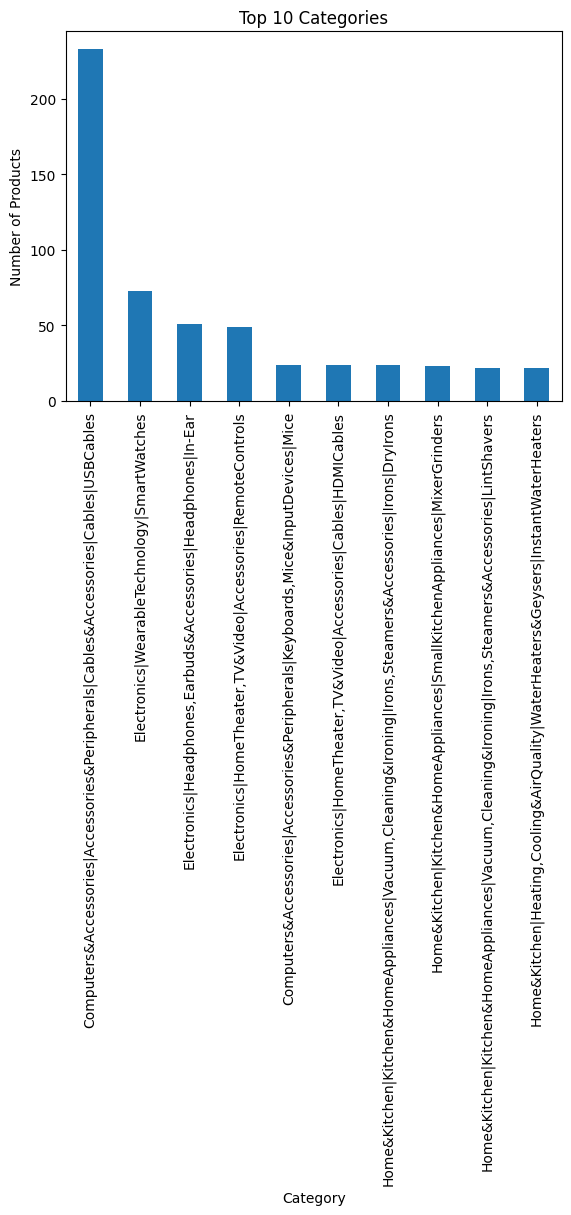

In [32]:
import matplotlib.pyplot as plt

# Count products in each category
top_categories = df_clean['category'].value_counts().head(10)

# Create bar chart
top_categories.plot(kind='bar')

# Add title and labels
plt.title("Top 10 Categories")
plt.xlabel("Category")
plt.ylabel("Number of Products")

# Show chart
plt.show()

In [33]:
# Save the cleaned dataset
df_clean.to_csv("cleaned_amazon_data.csv", index=False)

print("Project Completed Successfully!")

Project Completed Successfully!
